## Imports

In [1]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import ROI as r
import Vis as vis
import CompVis as comp_vis

## Main

#### variables

In [2]:
video_file = 'out/VID_20260207_081701560.mp4'
video_features = func.video_status(video_file, verbose = True)
nPC = 6
reduction_factor = 0.2

vpath: out/VID_20260207_081701560.mp4
fps: 240
width: 126
height: 162
frames: 800
duration: 3.33
mode: BGR
shape: (162, 126, 3)
rotation: 0


### pre-processing

In [ ]:
# r.roi_selection(in_video_path)
# pre_processing(in_video_path, out_video_path, video_features['frames'], video_features['fps'], reduction_factor, (24, 112, 620, 883))

### computer vision

In [3]:
unmixed = comp_vis.moses_code('out/VID_20260207_081701560.mp4', nPC)

In [ ]:
comp_vis.plot_pc(unmixed, video_features, range(nPC), save = True)

In [ ]:
comp_vis.plot_pc(unmixed, video_features, [1], w = 20, h = 6)

### variation over time

In [2]:
names = ['videos/8days/20260207/240/VID_20260207_081701560.mp4', 
         'videos/8days/20260208/240/VID_20260208_071551134.mp4',
         'videos/8days/20260209/240/VID_20260209_075208490.mp4',
         'videos/8days/20260210/240/VID_20260210_073714886.mp4',
         'videos/8days/20260211/240/VID_20260211_072715346.mp4',
         'videos/8days/20260212/240/VID_20260212_072409310.mp4',
         'videos/8days/20260213/240/VID_20260213_073426768.mp4',
         'videos/8days/20260214/240/VID_20260214_040340493.mp4']

In [32]:
r.roi_selection(names[7])

In [21]:
rois = [(25, 148, 631, 819),
        (12, 169, 689, 814),
        (10, 132, 680, 823),
        (10, 89, 699, 851),
        (6, 125, 689, 804),
        (5, 146, 670, 785),
        (10, 120, 680, 830),
        (8, 112, 687, 800)]

In [35]:
reduction_factor = 0.2
out_video_path = 'out/'
nframes = 800
fps = 240

for i, (name, roi) in enumerate(zip(names, rois)):
    print(f'{name} processing...', end = ' ')
    vf = func.video_status(name)
    comp_vis.pre_processing(name, out_video_path + name.split('/')[-1], nframes, fps, reduction_factor, roi)
    print(f'done.')

videos/8days/20260207/240/VID_20260207_081701560.mp4 processing... done.
videos/8days/20260208/240/VID_20260208_071551134.mp4 processing... done.
videos/8days/20260209/240/VID_20260209_075208490.mp4 processing... done.
videos/8days/20260210/240/VID_20260210_073714886.mp4 processing... done.
videos/8days/20260211/240/VID_20260211_072715346.mp4 processing... done.
videos/8days/20260212/240/VID_20260212_072409310.mp4 processing... done.
videos/8days/20260213/240/VID_20260213_073426768.mp4 processing... done.
videos/8days/20260214/240/VID_20260214_040340493.mp4 processing... done.


In [ ]:
nPC = 8

results = []
for name in names:
    video_file = 'out/' + name.split('/')[-1]
    unmixed = comp_vis.moses_code(video_file, nPC)
    
    vf = func.video_status(video_file, verbose = False)
    results.append(comp_vis.plot_pc(unmixed, vf, range(nPC), save = False))

In [17]:
results2 = {}

for d in results:
    for k, v in d.items():
        if k not in results2:
            results2[k] = []
        results2[k].append(v)

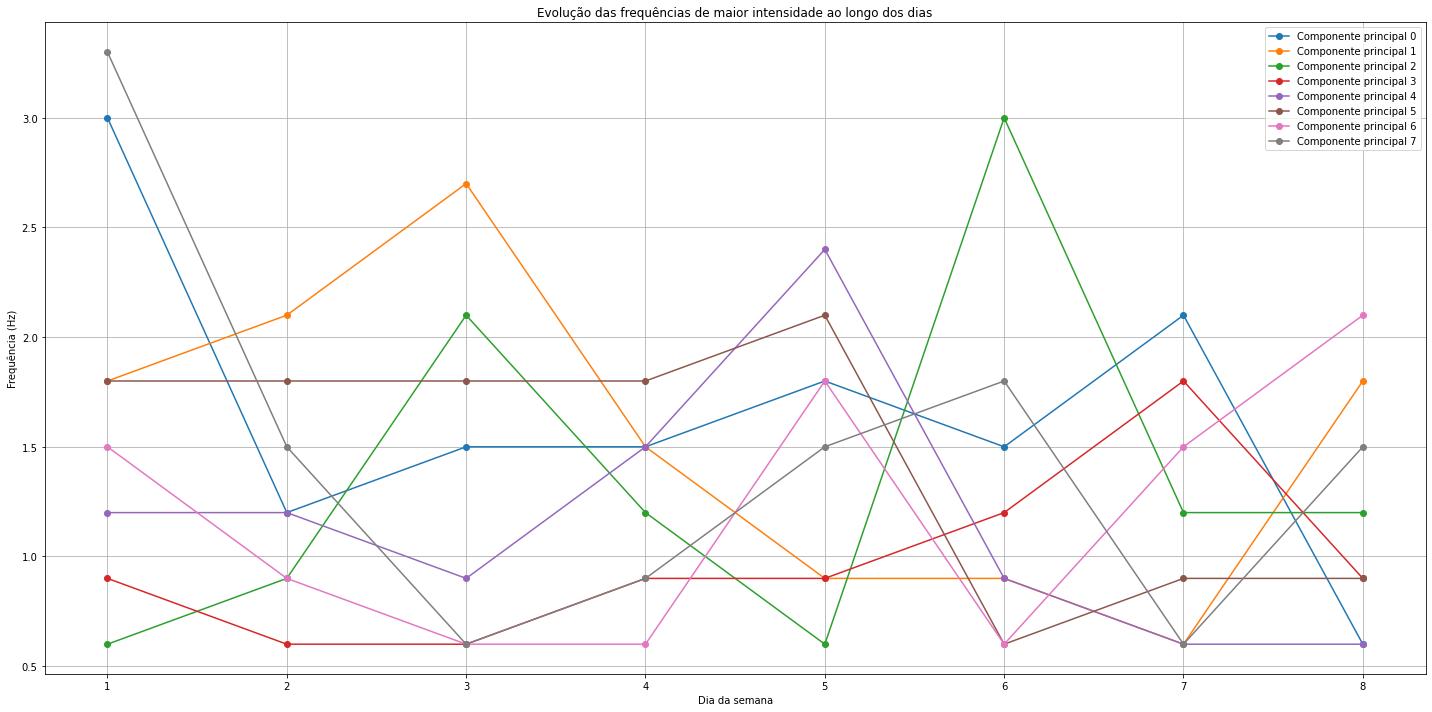

In [18]:
dias = list(range(1, 9))

plt.figure(figsize=(20, 10))

for componente, valores in results2.items():
    plt.plot(dias, valores, marker='o', label=f'Componente principal {componente}')

plt.xlabel('Dia da semana')
plt.ylabel('Frequência (Hz)')
plt.title('Evolução das frequências de maior intensidade ao longo dos dias')
plt.xticks(dias)
plt.legend()
plt.grid(True)
plt.tight_layout()

### spectrogram

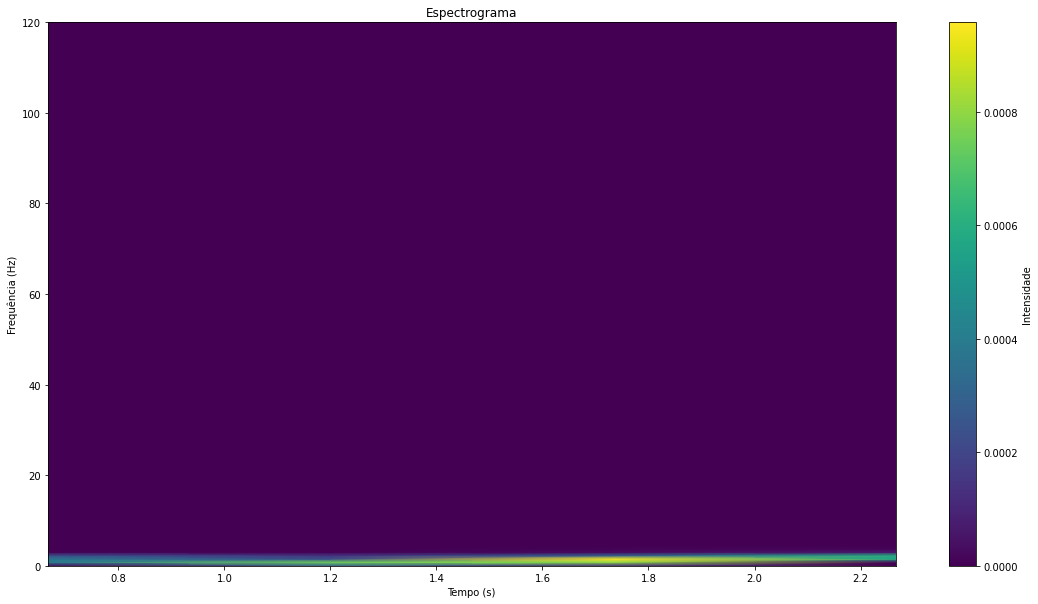

<Figure size 432x288 with 0 Axes>

In [21]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

fs = 240 # fps do vídeo

f, t, Sxx = spectrogram(
    unmixed[:, 1],
    fs=fs,
    window='hann',
    nperseg=320,
    noverlap=192
)
plt.figure(figsize = [19, 10])
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequência (Hz)")
plt.xlabel("Tempo (s)")
plt.title("Espectrograma")
plt.colorbar(label="Intensidade")
plt.show()
plt.savefig('out/spect.png', bbox_inches = 'tight')